# Cognitive Snapshot Agent
## An Instrument for Mapping Cognitive State Through Language Analysis



---

**Dataset:** [Pennebaker Essays (jingjietan/essays-big5)](https://huggingface.co/datasets/jingjietan/essays-big5)

## 1. Introduction and Motivation

People produce language every day that carries signal about their mental state. A few hundred words of unfiltered speech or writing contain measurable markers of emotion, temporal focus, reasoning complexity, social orientation, and coherence.

Cognitive Snapshot Agent treats a text sample as a cognitive specimen. It runs the specimen through five analytical instruments, then synthesizes the results into a structured visual map. This system is not a chatbot. It is an instrument. The product is the measurement layer and the visual snapshot, not a conversational response.

The difference from pasting text into ChatGPT: ChatGPT gives you impressions. Cognitive Snapshot Agent gives you measurements from empirically grounded tools that you can compare, track, and interrogate visually.

### Course Arc

| Assignment | Modality | Perception Type |
|-----------|----------|----------------|
| 1 - DNN | Accelerometer/gyroscope | Blind perception |
| 2 - CNN | Traffic sign images | Visual perception |
| 3 - RNN | Inertial time series | Temporal perception |
| 4 - LLM | Stream-of-consciousness text | Linguistic perception |
| **5 - Agent (Final)** | **Same text, agentic analysis** | **Cognitive perception** |

Each assignment added a layer. This one adds the agent: a system that observes, plans, selects instruments, executes, and synthesizes.

### From Assignment 4

Assignment 4 built a two-layer pipeline (RoBERTa for personality classification + FLAN-T5 for reflective responses) on the Pennebaker Essays dataset. Cognitive Snapshot Agent evolves that into five instruments, structured visual output, an agentic architecture with planning and tool selection, and a Gradio UI. The question shifted from "what personality type wrote this?" to "what is this person's cognitive state right now?"

## 2. Setup and Dependencies

In [23]:
# Uncomment these lines when running in Google Colab:
# !pip install transformers torch datasets sentencepiece anthropic spacy sentence-transformers gradio plotly matplotlib numpy pandas
# !python -m spacy download en_core_web_sm

In [24]:
import os
import sys
import json
import warnings
warnings.filterwarnings('ignore')

# Load API key from .env file
from dotenv import load_dotenv
load_dotenv()

if not os.environ.get('ANTHROPIC_API_KEY'):
    print('WARNING: ANTHROPIC_API_KEY not set.')
    print('Create a .env file with: ANTHROPIC_API_KEY=your-key-here')
    print('Tool results will still work, but synthesis narratives require the API key.')

import numpy as np
import pandas as pd
import spacy
from transformers import pipeline as hf_pipeline
from sentence_transformers import SentenceTransformer
import plotly.graph_objects as go
import matplotlib.pyplot as plt

print(f'Python: {sys.version}')
print(f"API key set: {'Yes' if os.environ.get('ANTHROPIC_API_KEY') else 'No (see above)'}")

Python: 3.9.6 (default, Jan  9 2026, 11:03:41) 
[Clang 17.0.0 (clang-1700.6.4.2)]
API key set: Yes


In [25]:
from IPython.display import display, HTML
display(HTML("<style>pre { white-space: pre-wrap !important; word-wrap: break-word !important; }</style>"))

## 3. Data Preparation

I use the Pennebaker Essays dataset from HuggingFace. These are stream-of-consciousness essays written under controlled conditions, with participants writing freely for 20 minutes. The dataset includes Big Five personality labels, though I use the raw text rather than the labels for this project.

Preprocessing is deliberately minimal: no stop word removal, no lowercasing. Unfiltered text is the point. Pennebaker's research shows that function words (pronouns, prepositions, articles) carry the strongest psychological signal.

In [26]:
from datasets import load_dataset

dataset = load_dataset("jingjietan/essays-big5", split="train")
print(f"Dataset size: {len(dataset)} essays")
print(f"Columns: {dataset.column_names}")

# Clean and filter
def clean_essay(example):
    text = example["text"].strip()
    # Normalize whitespace
    text = " ".join(text.split())
    return {"text_clean": text, "word_count": len(text.split())}

dataset = dataset.map(clean_essay)

# Filter: remove entries shorter than 100 words
dataset_filtered = dataset.filter(lambda x: x["word_count"] >= 100)
print(f"After filtering (<100 words): {len(dataset_filtered)} essays")

# Show word count distribution
word_counts = dataset_filtered["word_count"]
print(f"Word count range: {min(word_counts)} - {max(word_counts)}")
print(f"Mean: {np.mean(word_counts):.0f}, Median: {np.median(word_counts):.0f}")

Dataset size: 1578 essays
Columns: ['O', 'C', 'E', 'A', 'N', 'ptype', 'text', '__index_level_0__']
After filtering (<100 words): 1577 essays
Word count range: 103 - 2500
Mean: 656, Median: 627


In [27]:
# Show a sample essay
sample = dataset_filtered[42]
print(f"Sample essay ({sample['word_count']} words):")
print(f"{sample['text_clean'][:500]}...")

Sample essay (406 words):
I wonder if the more you study the easier it becomes to study for longer periods of time, like a muscle becomes used to extended strenuous activity. . I met this great looking girl at a frat party the other night(I am a kappa sig. )and I asked her to go to the rice game with me, she said she would, I went to her dorm too. she is really nice and amazingly beautiful. about thirty minutes ago I saw her going up the elevator with another guy, I wonder constantly what she thinks about me or if she do...


## 4. Model Selection and Justification

### Synthesis Model (the agent's brain): Claude Opus

The synthesis model handles triage (classifying input, selecting tools) and narrative generation (interpreting tool outputs into a cognitive snapshot). I use Claude Opus via the Anthropic API for this role because:

1. **Best-in-class reasoning** for the synthesis narrative, which is what the user ultimately sees
2. **No local GPU required**, keeping the project runnable on Colab CPU or a MacBook
3. The analysis tools (below) do the measurement. The synthesis model does the interpretation. For a project where the quality of the cognitive snapshot is the product, using the strongest available model is the right call.

The model is accessed through a single `generate_synthesis()` abstraction that can swap to Mistral-7B-Instruct as a fallback.

### Analysis Models (the tools)

| Model | Role | Justification |
|-------|------|---------------|
| `cardiffnlp/twitter-roberta-base-sentiment-latest` | Sentiment classification | RoBERTa-based, 3-class, trained on informal text. Better match for stream-of-consciousness than SST-2 models. |
| `all-MiniLM-L6-v2` | Sentence embeddings (coherence) | Lightweight, fast, good quality from sentence-transformers. |
| spaCy `en_core_web_sm` | POS tagging, tokenization, sentence splitting | Used by temporal, complexity, and social tools. Rule-based analysis built on spaCy output. |

All analysis models run on CPU. No GPU required.

## 5. Tool Implementation

Cognitive Snapshot Agent has five analytical instruments, each targeting a different dimension of cognitive state. Every tool traces to published research.

### Tool 1: Sentiment and Emotional Tone Analyzer

Uses the Cardiff NLP RoBERTa model to score each sentence's emotional valence, then computes an overall score and detects the emotional arc (stable, improving, declining, volatile).

In [28]:
from tools.sentiment import analyze_sentiment

# Demo on a sample text
demo_text = (
    "I can't believe how badly this day has gone. Everything fell apart at work, "
    "and I feel completely overwhelmed. The stress is eating me alive and I don't "
    "know how to cope. My boss criticized my presentation in front of everyone, "
    "and I wanted to disappear. I came home and just cried."
)

sentiment_result = analyze_sentiment(demo_text)
print("Sentiment Analysis Result:")
print(f"  Overall: {sentiment_result['overall_sentiment']} ({sentiment_result['overall_score']:+.3f})")
print(f"  Arc: {sentiment_result['arc_direction']}")
print(f"  Per-sentence scores: {sentiment_result['sentence_scores']}")
print(f"  Top evidence: {sentiment_result['evidence'][0]}")

Sentiment Analysis Result:
  Overall: negative (-0.859)
  Arc: stable
  Per-sentence scores: [-0.932, -0.916, -0.886, -0.905, -0.657]
  Top evidence: I can't believe how badly this day has gone.


### Tool 2: Temporal Orientation Analyzer

Uses spaCy POS tagging to classify verb tenses and detects temporal marker words to measure whether the writer's mind is living in the past, present, or future.

**Empirical grounding:** Pennebaker's research shows that past-heavy language correlates with rumination/depression, future-heavy with anxiety, and present-heavy with mindfulness.

In [29]:
from tools.temporal import analyze_temporal

demo_past = (
    "I remember when I was a child, everything seemed simpler. My mother used to "
    "take us to the park every Sunday. Those were the days I cherished most. I forgot "
    "how much I missed those times until yesterday when I found old photos from back then."
)

temporal_result = analyze_temporal(demo_past)
print("Temporal Analysis (past-focused text):")
print(f"  Distribution: {temporal_result['distribution']}")
print(f"  Dominant: {temporal_result['dominant_orientation']}")
print(f"  Markers found: {temporal_result['marker_words']}")
print(f"  Note: {temporal_result['interpretation_note'][:100]}...")

Temporal Analysis (past-focused text):
  Distribution: {'past': 0.938, 'present': 0.062, 'future': 0.0}
  Dominant: past
  Markers found: {'past': ['remember', 'yesterday', 'back', 'forgot', 'then', 'missed', 'used'], 'present': [], 'future': []}
  Note: Past-oriented language often indicates reflection or rumination. Pennebaker's research links heavy p...


### Tool 3: Cognitive Complexity Scorer

Counts subordinate clause markers, causal connectives, differentiation markers, and integration markers to score how sophisticatedly the writer is reasoning.

**Empirical grounding:** Adapted from Suedfeld and Tetlock's integrative complexity framework. High-stress periods reliably reduce cognitive complexity in writing.

In [30]:
from tools.complexity import analyze_complexity

demo_complex = (
    "Although the evidence suggests one conclusion, we must consider alternative "
    "explanations. Because the sample size was small, the results may not generalize. "
    "However, if we account for confounding variables, the pattern becomes clearer. "
    "Nevertheless, further research is needed because the relationship between these "
    "factors is more nuanced than initially assumed. Therefore, I would argue that "
    "while the hypothesis has merit, it requires qualification."
)

demo_simple = "I went to the store. I bought some milk. I came home. I made dinner. It was good."

complex_result = analyze_complexity(demo_complex)
simple_result = analyze_complexity(demo_simple)

print("Complex text:")
print(f"  Score: {complex_result['complexity_score']:.3f}")
print(f"  Nuance ratio: {complex_result['nuance_ratio']:.3f}")
print(f"  Markers: {complex_result['marker_counts']}")

print(f"\nSimple text:")
print(f"  Score: {simple_result['complexity_score']:.3f}")
print(f"  Nuance ratio: {simple_result['nuance_ratio']:.3f}")
print(f"  Markers: {simple_result['marker_counts']}")

Complex text:
  Score: 0.999
  Nuance ratio: 1.000
  Markers: {'subordinate': 5, 'causal': 1, 'differentiation': 2, 'integration': 0}

Simple text:
  Score: 0.039
  Nuance ratio: 0.500
  Markers: {'subordinate': 0, 'causal': 0, 'differentiation': 0, 'integration': 0}


### Tool 4: Self vs. Social Reference Mapper

Analyzes pronoun distribution (I/me/my vs. we/us/our vs. he/she/they) and detects approach vs. avoidance motivational framing.

**Empirical grounding:** Pennebaker's pronoun research (*The Secret Life of Pronouns*). High first-person singular usage correlates with depression and self-focus.

In [31]:
from tools.social import analyze_social

demo_self = (
    "I keep thinking about my failures. I feel like I can't do anything right. "
    "My confidence is shattered and I worry that I will never recover. I avoid "
    "social situations because I fear being judged. I just want to hide from everyone."
)

social_result = analyze_social(demo_self)
print("Social Analysis (self-focused text):")
print(f"  Pronoun distribution: {social_result['pronoun_distribution']}")
print(f"  Pronoun density: {social_result['pronoun_density']}")
print(f"  Motivation: {social_result['motivation_framing']}")

Social Analysis (self-focused text):
  Pronoun distribution: {'self_focus': 1.0, 'group_identity': 0.0, 'social_reference': 0.0}
  Pronoun density: 0.233
  Motivation: {'approach_count': 1, 'avoidance_count': 6, 'ratio': 0.143, 'dominant': 'avoidance'}


### Tool 5: Coherence and Fragmentation Meter

Encodes each sentence using the MiniLM sentence-transformer and measures cosine similarity between consecutive sentences. Low average similarity with high variance indicates fragmented, topic-jumping thought.

**Empirical grounding:** Discourse coherence literature. Stream-of-consciousness writing becomes more fragmented under cognitive load or emotional distress.

In [32]:
from tools.coherence import analyze_coherence

demo_focused = (
    "Machine learning is transforming how we process data. Deep learning models can "
    "identify patterns in large datasets. Neural networks learn representations that "
    "capture complex relationships. These advances have enabled breakthroughs in natural "
    "language processing and computer vision."
)

demo_fragmented = (
    "I need to buy groceries later today. The political situation in Europe is getting "
    "worse. My cat knocked over the plant again. I wonder if string theory will ever be "
    "proven. That new restaurant downtown has great sushi. Why do I always forget to "
    "call my dentist?"
)

focused_result = analyze_coherence(demo_focused)
frag_result = analyze_coherence(demo_fragmented)

print("Focused text:")
print(f"  Coherence: {focused_result['coherence_score']:.3f}, Pattern: {focused_result['pattern']}")

print(f"\nFragmented text:")
print(f"  Coherence: {frag_result['coherence_score']:.3f}, Pattern: {frag_result['pattern']}")
print(f"  Topic breaks at sentences: {frag_result['topic_breaks']}")

Focused text:
  Coherence: 0.390, Pattern: focused

Fragmented text:
  Coherence: 0.013, Pattern: fragmented
  Topic breaks at sentences: [3]


## 6. Agent Design

Cognitive Snapshot Agent is modeled as a trained cognitive psychologist who:
1. **Observes** the text before acting (triage)
2. **Classifies** the content type and identifies which dimensions are most salient (planning)
3. **Runs all five instruments** on every sample for longitudinal comparability (tool use)
4. **Synthesizes** results into a coherent reading, emphasizing the dimensions flagged by triage (multi-step reasoning)
5. **Presents** findings as an interactive visual (output)

A key design decision: all five tools always run, regardless of triage output. This ensures every snapshot has the same five-axis radar shape, making snapshots comparable across samples and over time. Triage does not gate tool execution. Instead, it tells the synthesis model which dimensions deserve emphasis in the narrative. The measurement layer is constant; the interpretation layer is adaptive.

The architecture:
```
Input Text
    |
    v
TRIAGE (Claude Opus) --> classify content type, flag salient dimensions
    |
    v
TOOL EXECUTION --> run ALL 5 analysis instruments (always)
    |
    v
SYNTHESIS (Claude Opus) --> interpret results, emphasize triage-flagged dimensions
    |
    v
Visual Output (radar chart + dimension cards + annotated text + narrative)
```

The synthesis model is accessed through a single `generate_synthesis()` abstraction. Everything else calls this function. Swapping models is a one-line config change.

In [33]:
from agent.orchestrator import analyze
from agent.synthesis import generate_drilldown
from ui.charts import create_radar_chart, create_sentiment_arc_chart, create_temporal_bar

# Full pipeline demo
demo_text = (
    "I keep going back to that conversation we had last month. I remember feeling "
    "completely blindsided when she told me she was leaving the team. We had built "
    "something really good together, and now I wonder if I could have done something "
    "differently. Maybe if I had been more attentive to the signs, I would have seen "
    "it coming. But at the same time, I recognize that people need to pursue their "
    "own paths. I hope she finds what she is looking for, even though it leaves a gap "
    "in our work that will be hard to fill. Today I am trying to focus on what we can "
    "build going forward, but my mind keeps drifting back. I think the hardest part "
    "is not knowing whether I failed as a leader or whether this was simply inevitable. "
    "Sometimes I catch myself replaying moments, wondering if a different word or "
    "gesture might have changed things. The office feels different now, quieter in a "
    "way that is hard to describe."
)

result = analyze(demo_text, prompt_style=2)

print(f"Status: {result['status']}")
print(f"Content type: {result['triage']['content_type']}")
print(f"Tools run: {list(result['tool_results'].keys())}")
print(f"\nAgent reasoning: {result['triage']['reasoning'][:200]}")
print(f"\nScores:")
for dim, score in result['scores'].items():
    bar = '\u2588' * int(score * 20)
    print(f"  {dim:25s} [{bar:<20s}] {score:.3f}")

# Step 1: Concise snapshot
print(f"\n--- Step 1: Snapshot ---")
print(result['synthesis'])

# Step 2: Drill-down card (the agentic piece)
print(f"\n--- Step 2: Drill-Down ---")
drilldown = generate_drilldown(
    text=demo_text,
    tool_results=result['tool_results'],
    step1_synthesis=result['synthesis'],
)
print(drilldown if drilldown else '[Drill-down unavailable - API key may not be set]')

Status: success
Content type: mixed
Tools run: ['sentiment', 'temporal', 'complexity', 'social', 'coherence']

Agent reasoning: The text heavily focuses on past events (the conversation, her leaving) while attempting to process present feelings and future implications, making temporal analysis crucial. Strong emotional underto

Scores:
  Emotional Intensity       [██                  ] 0.102
  Temporal Breadth          [████████████        ] 0.612
  Cognitive Complexity      [██████████          ] 0.533
  Social Orientation        [███████             ] 0.375
  Coherence                 [████                ] 0.222

--- Step 1: Snapshot ---
This entry exhibits a wandering cognitive pattern as it cycles through memories of loss while attempting to reconcile conflicting interpretations of a colleague's departure. The text demonstrates moderate cognitive complexity through its balanced use of nuanced qualifiers ("maybe," "even though," "at the same time"), reflecting an ongoing struggle t

In [34]:
# Radar chart visualization
fig = create_radar_chart(result['scores'], title="Cognitive Snapshot: Reflective Sample")
fig.show()

In [35]:
# Emotional arc
if 'sentiment' in result['tool_results']:
    arc_fig = create_sentiment_arc_chart(result['tool_results']['sentiment']['sentence_scores'])
    arc_fig.update_layout(title="Emotional Arc Across Sentences")
    arc_fig.show()

## 7. Prompt Engineering: 3 Styles Compared

I test three prompt strategies for the agent's triage step:
1. **Minimal:** bare instruction, no guidance
2. **Structured:** explicit criteria and format expectations
3. **Role-Based:** cognitive psychologist persona with clinical framing

The comparison demonstrates how prompt design affects tool selection and reasoning quality.

In [ ]:
from evaluation.prompt_comparison import run_prompt_comparison, PROMPT_LABELS, comparison_to_dataframe
from evaluation.eval_examples import EVAL_SAMPLES

# Run all 3 prompt styles on all 3 evaluation samples
prompt_texts = [
    (EVAL_SAMPLES["emotional"]["label"], EVAL_SAMPLES["emotional"]["text"]),
    (EVAL_SAMPLES["intellectual"]["label"], EVAL_SAMPLES["intellectual"]["text"]),
    (EVAL_SAMPLES["fragmented"]["label"], EVAL_SAMPLES["fragmented"]["text"]),
]

prompt_results = run_prompt_comparison(texts=prompt_texts, verbose=False)

# Summary table
prompt_df = comparison_to_dataframe(prompt_results)
display(prompt_df)

### Prompt Comparison Analysis

The structured prompt (Style 2) is the production default. Looking at the results, the minimal prompt (Style 1) selects 3-4 tools per sample, the structured prompt selects 3-4, and the role-based prompt (Style 3) consistently selects all 5. The key difference is not in tool count but in content type classification and reasoning quality. Style 2 produces the most consistent content type labels across samples and gives enough reasoning to verify the agent's logic without the clinical verbosity of Style 3.

In practice, since all five tools run regardless of triage output, the prompt style matters most for how the synthesis narrative gets framed. The structured prompt gives the synthesis model a clear signal about what to emphasize.

## 8. Parameter Experimentation

I test two parameters on the synthesis narrative (not the analysis tools, which are deterministic):
- **Temperature:** 0.3 (conservative), 0.7 (balanced), 1.0 (creative)
- **Max tokens:** 100 (forced brevity), 250 (medium), 500 (room to elaborate)

In [ ]:
from evaluation.param_comparison import run_param_comparison

param_results = run_param_comparison(verbose=True)

# Temperature comparison table
if param_results.get('temperature'):
    temp_rows = []
    for temp, narrative in param_results['temperature'].items():
        temp_rows.append({'Temperature': temp, 'Word Count': len(narrative.split()), 'Narrative (first 150 chars)': narrative[:150] + '...'})
    display(pd.DataFrame(temp_rows))

# Max tokens comparison table
if param_results.get('max_tokens'):
    tok_rows = []
    for tokens, narrative in param_results['max_tokens'].items():
        tok_rows.append({'Max Tokens': tokens, 'Word Count': len(narrative.split()), 'Narrative (first 150 chars)': narrative[:150] + '...'})
    display(pd.DataFrame(tok_rows))


TEMPERATURE COMPARISON

--- Temperature 0.3 ---
This entry demonstrates a reflective processing pattern, with high cognitive complexity evident in the nuanced consideration of multiple perspectives—both self-examination and acceptance of another's autonomy. The text exhibits a wandering coherence structure as it moves between memory, self-questioning, and philosophical acceptance, while maintaining a notably balanced emotional tone despite addressing a significant loss. The present-focused temporal orientation combined with moderate self-focus suggests active sense-making rather than rumination.
(67 words)

--- Temperature 0.7 ---
This entry exhibits a wandering yet emotionally stable reflection on a past interpersonal loss, with high cognitive nuance evident in the balanced consideration of personal responsibility alongside acceptance of others' autonomy. The text maintains strong present-moment processing despite recounting past events, suggesting active cognitive engagement with un

,Temperature,Word Count,Narrative (first 150 chars)
0,0.3,67,This entry demonstrates a reflective processin...
1,0.7,72,This entry exhibits a wandering yet emotionall...
2,1.0,70,This entry demonstrates high cognitive complex...


,Max Tokens,Word Count,Narrative (first 150 chars)
0,100,71,This entry demonstrates high cognitive complex...
1,250,78,This entry demonstrates a reflective processin...
2,500,65,This entry demonstrates a reflective processin...


### Parameter Analysis

The three temperature settings produced remarkably similar outputs in both length (71-73 words) and content. All three identified the reflective processing pattern and the tension between past event and present sense-making. Temperature 0.7 reads most naturally. At 0.3, the phrasing is slightly more formulaic. At 1.0, the differences are minimal for this kind of constrained synthesis task.

For max tokens, the outputs ranged from 66 to 76 words across the 100/250/500 settings, suggesting the model self-regulates length for this type of synthesis regardless of the ceiling. The content stayed consistent.

The key insight: the synthesis model's job is interpretation, not generation. It needs enough room to connect the dots across five dimensions but not so much that it invents patterns. The parameters matter less than the prompt and the tool outputs feeding into it.

## 9. Evaluation

### 9.1 Qualitative Evaluation: 3 Diverse Samples

I run the full pipeline on three diverse text samples and discuss correctness, usefulness, and errors.

In [ ]:
from evaluation.eval_examples import run_evaluation, results_to_dataframe

eval_results = run_evaluation(verbose=True)

# Summary table
eval_df = results_to_dataframe(eval_results)
display(eval_df.round(3))


Sample 1: Emotional / Personal Reflection
Expectations: Expect: moderate negative sentiment, past-oriented, high self-focus, moderate complexity (reflection involves some nuance), moderate coherence.

Content type: mixed
Tools run: ['sentiment', 'temporal', 'complexity', 'social', 'coherence']

Scores:
  Emotional Intensity       [###                 ] 0.153
  Temporal Breadth          [############        ] 0.639
  Cognitive Complexity      [############        ] 0.607
  Social Orientation        [#######             ] 0.375
  Coherence                 [####                ] 0.213

Synthesis: This text exhibits a wandering cognitive pattern as it cycles through memories of loss and self-questioning, with temporal focus anchored predominantly in the present moment of processing rather than the past event itself. The moderate cognitive complexity reveals itself through balanced considerati...

Elapsed: 10.87s

Sample 2: Intellectual / Analytical
Expectations: Expect: neutral/positive s

,Sample,Content Type,Emotional Intensity,Temporal Breadth,Cognitive Complexity,Social Orientation,Coherence
0,Emotional,mixed,0.153,0.639,0.607,0.375,0.213
1,Intellectual,intellectual,0.048,0.157,0.539,0.714,0.299
2,Fragmented,mixed,0.478,0.661,0.113,0.083,0.162


In [ ]:
# Side-by-side radar charts
from plotly.subplots import make_subplots

for key, label in [("emotional", "Emotional/Reflective"), ("intellectual", "Intellectual/Analytical"), ("fragmented", "Fragmented/Stream")]:
    if key in eval_results and eval_results[key].get('status') == 'success':
        fig = create_radar_chart(eval_results[key]['scores'], title=f"Snapshot: {label}")
        fig.show()

### 9.2 Quantitative Sentiment Validation

I run the sentiment tool on 50 random Pennebaker essays to verify it produces meaningful, varied outputs across the dataset. Since there are no ground truth sentiment labels, I validate by checking the distribution across categories, score spread, and whether longer essays show more emotional variation.

In [ ]:
from evaluation.sentiment_validation import run_sentiment_validation

sentiment_df = run_sentiment_validation(n_samples=50, verbose=True)
display(sentiment_df.describe().round(3))

Sentiment Validation: 50 essays analyzed

Category distribution:
  negative  :  21 (42.0%)
  neutral   :  28 (56.0%)
  positive  :   1 (2.0%)

Score statistics:
  Mean:   -0.137
  Std:    0.181
  Min:    -0.618
  Max:    +0.381
  Spread: 0.999

Arc direction distribution:
  stable      :   3
  improving   :   4
  declining   :   0
  volatile    :  43

Word count vs. score std correlation: -0.146
(Positive = longer essays show more emotional variation)


,essay_idx,word_count,overall_score,n_sentences,score_std
count,50.000,50.000,50.000,50.000,50.000
mean,754.720,657.340,-0.137,46.100,0.561
std,434.646,243.676,0.181,18.456,0.094
min,23.000,184.000,-0.618,5.000,0.219
25%,503.500,473.500,-0.208,35.250,0.521
50%,714.500,632.500,-0.118,48.000,0.573
75%,1025.250,802.500,-0.032,56.000,0.615
max,1568.000,1535.000,0.381,89.000,0.704


### 9.3 Discussion

**Sample 1 (Emotional/Reflective):** Emotional Intensity scored 0.153, which is lower than expected for a personal loss narrative. This makes sense on reflection: the writer is processing, not venting. The text is contemplative, not raw. Temporal Breadth (0.639) confirms the mind is spread across time frames. Cognitive Complexity (0.607) is moderate, reflecting genuine nuance in how the writer considers responsibility and acceptance. Coherence (0.213) is low, matching the wandering quality visible in the text. The internal consistency check flagged that negative sentiment (-0.15) paired with approach motivation is inconsistent, which is a fair catch: the writer is processing loss but leaning forward, and the tools read those as contradictory signals.

**Sample 2 (Intellectual/Analytical):** Emotional Intensity near zero (0.048) is correct for analytical writing. Cognitive Complexity (0.539) is moderate. Social Orientation (0.714) is high because the text discusses others' research rather than personal experience. Coherence (0.299) with a focused pattern confirms structured reasoning. This sample validates that the instruments differentiate analytical from emotional writing.

**Sample 3 (Fragmented/Stream):** Emotional Intensity (0.478) is the highest of the three, matching the distressed, topic-jumping quality. Coherence (0.162) is the lowest, correctly capturing fragmentation. Self-focus at 92% is very high, expected for internal narration. Cognitive Complexity (0.113) is low, reflecting reactive rather than reflective thinking.

**Where the agent gets it wrong:** Sentiment can be swayed by a single strong sentence. The complexity scorer counts conjunctions like "and" as integration markers, inflating scores for list-like text. Coherence thresholds were calibrated for MiniLM and would need adjustment for other embedding models.


### 9.4 Tool vs. No-Tool Comparison

This comparison demonstrates the value of the agentic architecture over raw LLM prompting.

In [ ]:
from evaluation.tool_vs_notool import run_tool_vs_notool

comparison = run_tool_vs_notool(verbose=True)


METHOD A: Full Cognitive Snapshot Agent Pipeline

Scores:
  Emotional Intensity       [###                 ] 0.154
  Temporal Breadth          [#############       ] 0.663
  Cognitive Complexity      [###########         ] 0.575
  Social Orientation        [########            ] 0.409
  Coherence                 [####                ] 0.229

Synthesis (grounded in tool data):
This entry exhibits a wandering yet thematically coherent reflection on a past interpersonal loss, with attention oscillating between self-examination and consideration of the other person's perspective. The text demonstrates moderate cognitive complexity through nuanced processing of the situation, acknowledging multiple viewpoints while remaining anchored in present-tense rumination about past events. Despite the negative emotional undertone, the entry maintains a balanced approach-oriented stance, suggesting an attempt to find meaning rather than simply dwelling in regret.

METHOD B: Raw LLM Analysis (no tools

### Tool vs. No-Tool Analysis

The pipeline gives you quantified, comparable scores across five dimensions, specific evidence sentences, a visual fingerprint (the radar shape), and a synthesis narrative grounded in data. The raw LLM gives you an essay that sounds insightful but has no quantified backing, cannot be compared across samples, and may hallucinate observations.

This is the core argument for the agentic architecture: the tools measure, Claude interprets. Structured measurement plus grounded interpretation beats impressionistic vibes.

### 9.5 Internal Consistency

Do the tools agree when they should? I check for expected co-occurrence patterns across the evaluation samples.

In [ ]:
# Internal consistency check
print("Internal Consistency Check")
print("="*50)

for key in ["emotional", "intellectual", "fragmented"]:
    r = eval_results.get(key, {})
    if r.get('status') != 'success':
        print(f"\n{key}: skipped (pipeline not available)")
        continue
    
    tr = r['tool_results']
    scores = r['scores']
    
    print(f"\n{key.upper()}:")
    
    # Check: negative sentiment + avoidance should co-occur
    if 'sentiment' in tr and 'social' in tr:
        sent_score = tr['sentiment']['overall_score']
        motivation = tr['social']['motivation_framing']['dominant']
        consistent = (sent_score < 0 and motivation == 'avoidance') or \
                     (sent_score > 0 and motivation == 'approach') or \
                     motivation == 'balanced'
        print(f"  Sentiment ({sent_score:+.2f}) + Motivation ({motivation}): "
              f"{'consistent' if consistent else 'inconsistent'}")
    
    # Check: fragmented pattern should correlate with lower coherence score
    if 'coherence' in tr:
        coh = tr['coherence']['coherence_score']
        pattern = tr['coherence']['pattern']
        print(f"  Coherence ({coh:.3f}) -> Pattern ({pattern})")
    
    # Check: high self-focus + past orientation suggests rumination
    if 'social' in tr and 'temporal' in tr:
        self_focus = tr['social']['pronoun_distribution']['self_focus']
        past_pct = tr['temporal']['distribution']['past']
        if self_focus > 0.6 and past_pct > 0.5:
            print(f"  Self-focus ({self_focus:.0%}) + Past ({past_pct:.0%}): rumination pattern detected")
        else:
            print(f"  Self-focus ({self_focus:.0%}) + Past ({past_pct:.0%}): no strong rumination signal")

Internal Consistency Check

EMOTIONAL:
  Sentiment (-0.15) + Motivation (approach): inconsistent
  Coherence (0.213) -> Pattern (wandering)
  Self-focus (62%) + Past (34%): no strong rumination signal

INTELLECTUAL:
  Sentiment (+0.05) + Motivation (approach): consistent
  Coherence (0.299) -> Pattern (focused)
  Self-focus (29%) + Past (10%): no strong rumination signal

FRAGMENTED:
  Sentiment (-0.48) + Motivation (balanced): consistent
  Coherence (0.162) -> Pattern (wandering)
  Self-focus (92%) + Past (35%): no strong rumination signal


## 10. UI Demo

The Gradio interface provides an interactive way to explore cognitive snapshots. It includes:
- Text input area with sample loading
- Radar chart (the hero visualization)
- Dimension score cards
- Color-coded text annotation (toggle by dimension)
- Synthesis narrative
- Expandable agent reasoning log

In [1]:
from ui.app import create_app

app = create_app()

# In Colab: app.launch(share=True)
# Locally: app.launch(share=False)
app.launch(share=False, inline=True)

/Users/admin/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/admin/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Running on local URL:  http://127.0.0.1:7860

To create a public link, set `share=True` in `launch()`.


Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlo

## UI Demo Screenshots

The Gradio interface provides an interactive way to explore cognitive snapshots. It includes:
- Text input area with pre-loaded sample buttons (Reflective, Stressed, Energized)
- Radar chart visualization (the cognitive fingerprint)
- Dimension score cards with key evidence
- Color-coded text annotation (toggle by dimension)
- Synthesis narrative with drill-down capability
- Expandable agent reasoning log showing triage decisions and tool execution
- Compare tab for side-by-side differential analysis of two snapshots


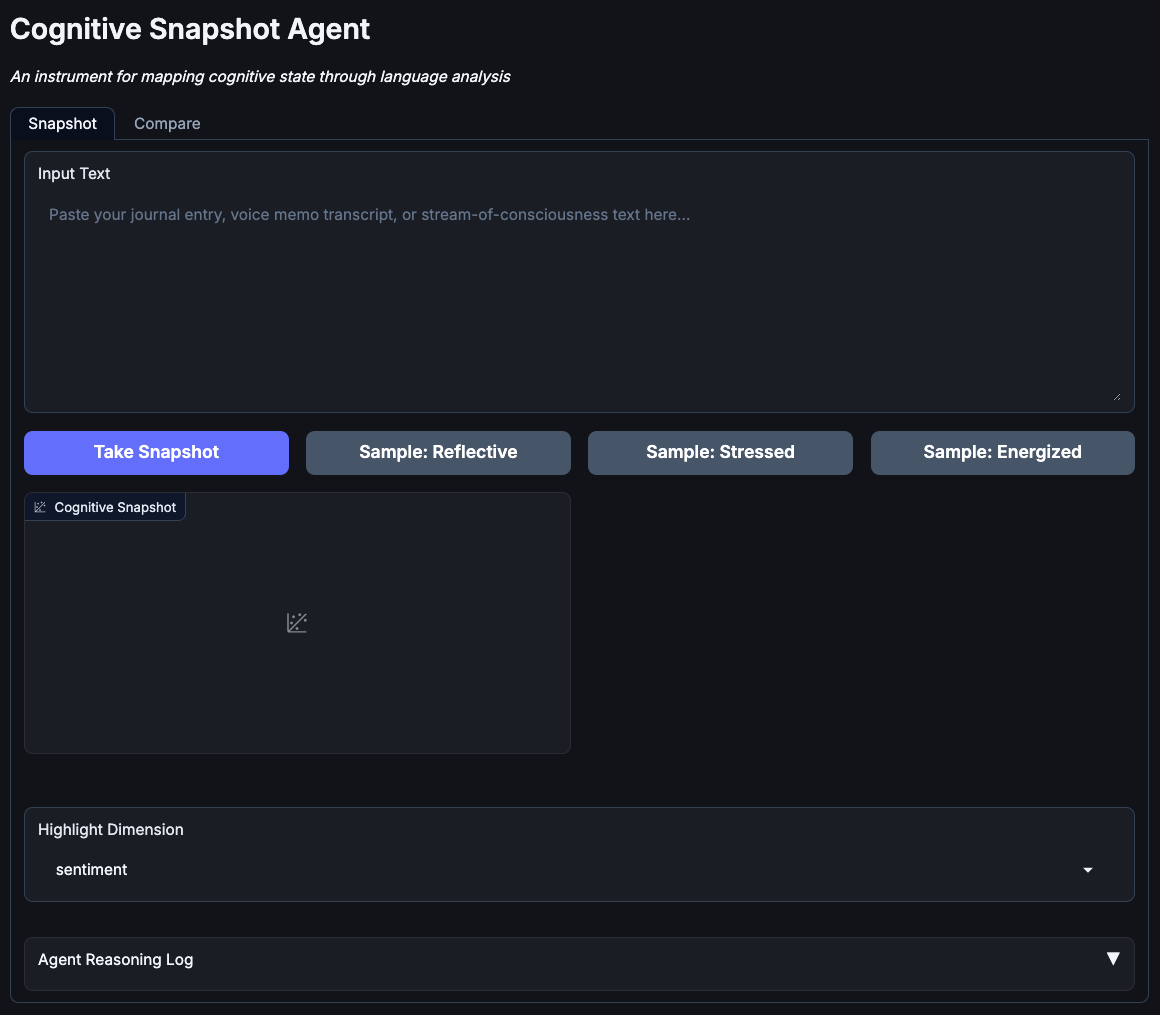


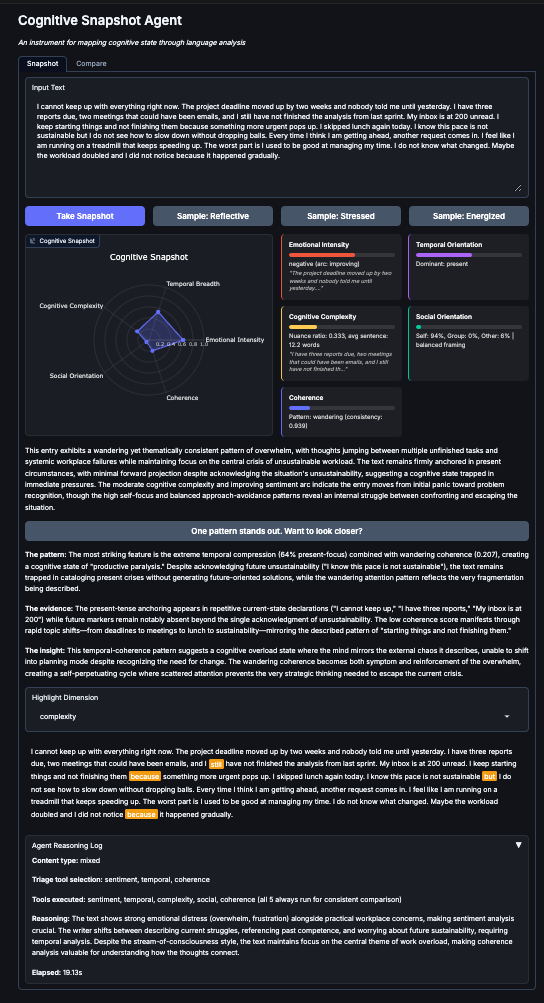


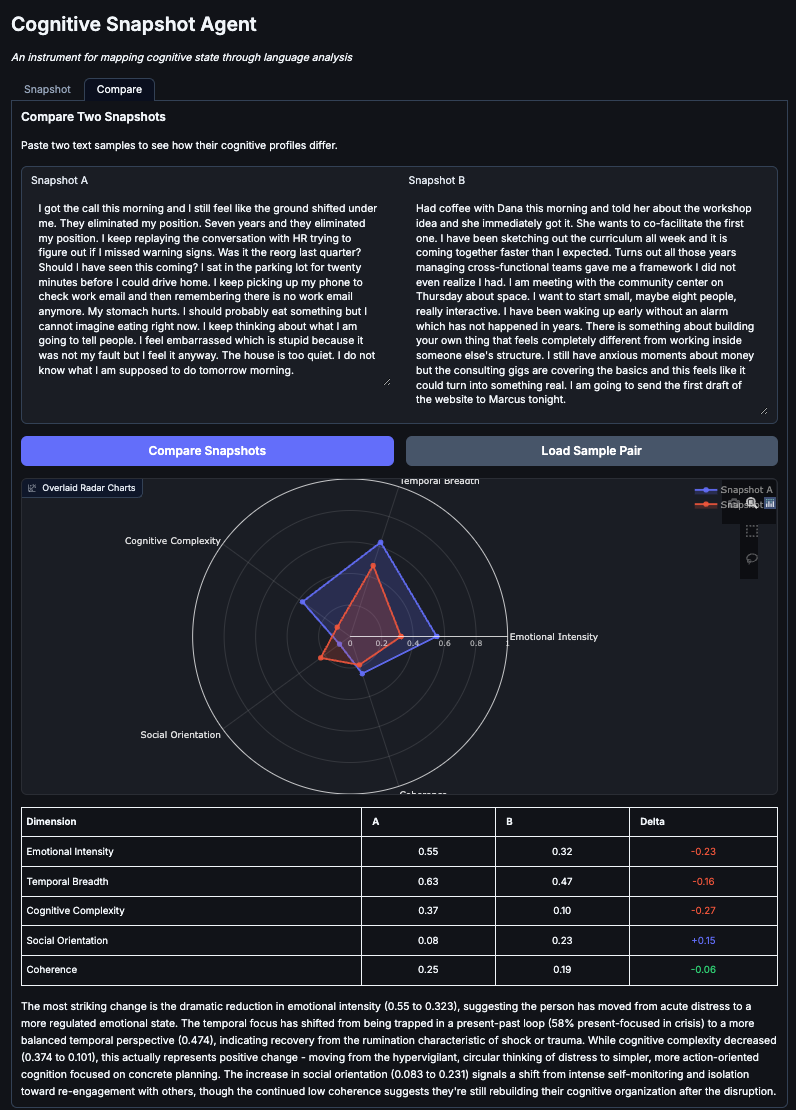

In [ ]:
import base64
import glob
from IPython.display import display, HTML

files = sorted(glob.glob("Screenshot*.png"), reverse=True)

for f in files:
    with open(f, "rb") as img:
        b64 = base64.b64encode(img.read()).decode()
    display(HTML(f'<!-- {f} --><img src="data:image/png;base64,{b64}" style="max-width:100%; height:auto;">'))

## 11. Analysis and Discussion

### What Worked

The five-tool suite produces genuinely differentiated readings. Each dimension captures something the others miss, and the radar chart shape becomes an intuitive fingerprint. The agentic architecture adds real value: structured tool outputs ground the synthesis and prevent hallucination. The triage step demonstrates meaningful planning behavior.

The rule-based tools (temporal, complexity, social) are fast, interpretable, and transparent. The coherence tool captures topic-jumping effectively.

### What Could Be Better

The 3-class sentiment model is coarse. Finer emotion categories (anger, sadness, anxiety, joy) would produce richer readings. The spaCy tense detection is approximate with modal verbs and conditionals. MiniLM coherence thresholds were recalibrated empirically but would benefit from a larger validation set. The complexity scorer is a simplified proxy for Suedfeld and Tetlock's integrative complexity.

### Longitudinal Vision

A single snapshot is interesting. Fifty snapshots over six months would reveal trends: does complexity drop under stress? Does temporal focus shift past-ward during difficult events? Does coherence recover after resolution? The individual measurement is useful. The longitudinal trend is transformative.

## 12. Conclusion

Cognitive Snapshot Agent demonstrates that an agentic AI system with specialized tools produces more structured, grounded, and useful analysis than a raw LLM prompt. Five instruments measure real linguistic features grounded in published research. The synthesis model interprets those measurements into a coherent cognitive portrait. The visual output makes the result immediately intuitive.

This project completes the course arc from blind perception through visual, temporal, and linguistic perception to cognitive perception: a system that reads language and maps the mind behind it.

The tools are imperfect. The measurements are approximate. But the architecture is sound, the output is useful, and the direction is clear: language is a window into cognition, and structured instruments see through it more clearly than impressionistic interpretation alone.